In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

# 0. Calculate the Performance Metrics

In [3]:
rename_datasets = {'esol_delaney': 'ESOL',
                   'solubility_mobley': 'Mobley',
                   'mutagenicity': 'Ames',
                   }

## 0.1 Regression

In [15]:
reg_files = ['./rf_regression_solubility/df_performance.pkl']
df_reg = pd.concat((pd.read_pickle(reg_file) for reg_file in reg_files))
df_reg['dataset'] = df_reg['dataset'].replace(rename_datasets)

In [16]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
df_reg['MAE'] = df_reg.apply(lambda x: mean_absolute_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_reg['RMSE'] = df_reg.apply(lambda x: root_mean_squared_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_reg['R²'] = df_reg.apply(lambda x: r2_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)

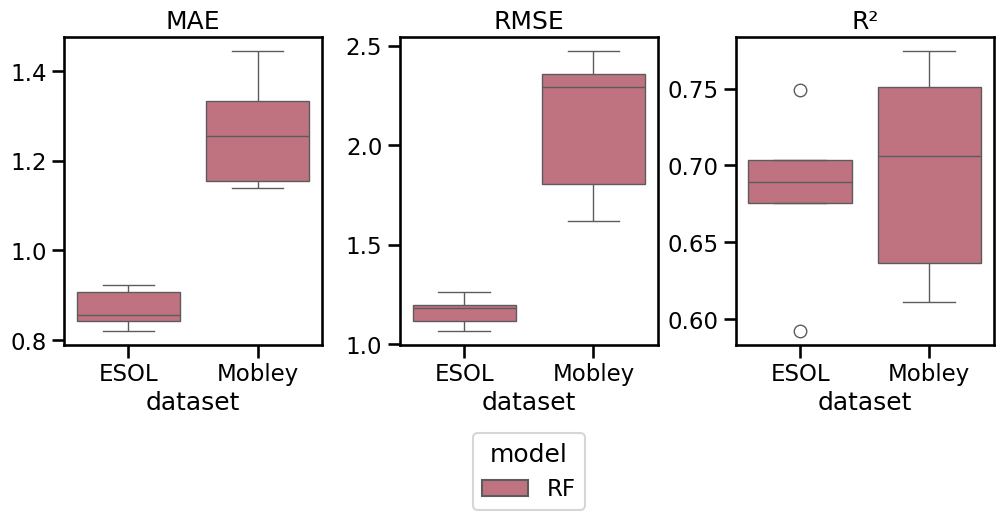

In [17]:
reg_metrics_of_interest = ['MAE', 'RMSE', 'R²']
fig, axs = plt.subplots(1, 
                        len(reg_metrics_of_interest),
                        figsize=(12, 4))
for idx, reg_metric in enumerate(reg_metrics_of_interest):
    sns.boxplot(df_reg,
                x='dataset',
                y=reg_metric,
                hue='model',
                ax=axs[idx])
    axs[idx].set_ylabel('')
    axs[idx].set_title(reg_metric)

axs[0].get_legend().remove()
axs[2].get_legend().remove()
axs[1].legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', title='model')

plt.subplots_adjust(wspace=0.3) # for better spacing
fig.savefig(os.path.join(fig_folder, '1_reg_boxplots.pdf'), 
            bbox_inches='tight',
            )

In [18]:
df_reg[['dataset', 'model']+reg_metrics_of_interest].groupby(['dataset', 'model']).agg(['mean', 'std'])

MAE                RMSE                  R²          
                   mean       std      mean       std      mean       std
dataset model                                                            
ESOL    RF     0.869779  0.043888  1.166011  0.075962  0.681844  0.057274
Mobley  RF     1.265332  0.127468  2.109725  0.373927  0.695854  0.070950

In [19]:
reg_latex_out = df_reg[['dataset', 'model']+reg_metrics_of_interest].groupby(['dataset', 'model']).agg(['mean', 'std']).to_latex(index=False,
                                                                                                                              float_format="%.3f")
print(reg_latex_out)

\begin{tabular}{rrrrrr}
\toprule
\multicolumn{2}{r}{MAE} & \multicolumn{2}{r}{RMSE} & \multicolumn{2}{r}{R²} \\
mean & std & mean & std & mean & std \\
\midrule
0.870 & 0.044 & 1.166 & 0.076 & 0.682 & 0.057 \\
1.265 & 0.127 & 2.110 & 0.374 & 0.696 & 0.071 \\
\bottomrule
\end{tabular}



## 0.2 Classification 

In [20]:
class_files = ['./rf_classification_mutagenicity/df_performance.pkl']
df_class = pd.concat((pd.read_pickle(class_file) for class_file in class_files))
df_class['dataset'] = df_class['dataset'].replace(rename_datasets)

In [21]:
from sklearn.metrics import balanced_accuracy_score, f1_score, matthews_corrcoef
df_class['BACC'] = df_class.apply(lambda x: balanced_accuracy_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_class['F1'] = df_class.apply(lambda x: f1_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_class['MCC'] = df_class.apply(lambda x: matthews_corrcoef(y_true=x.y_test, y_pred=x.y_pred), axis=1)

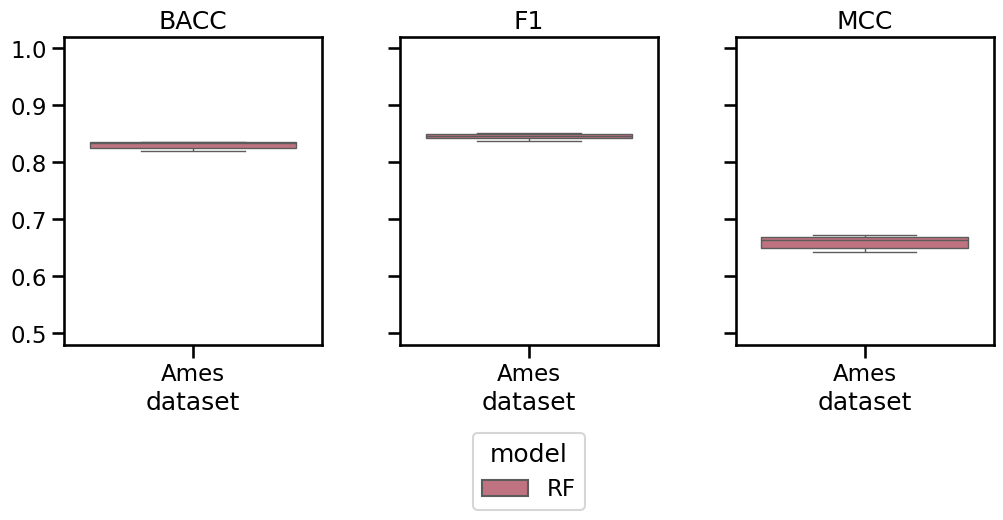

In [22]:
class_metrics_of_interest = ['BACC', 'F1', 'MCC']
fig, axs = plt.subplots(1, 
                        len(class_metrics_of_interest),
                        figsize=(12, 4),
                        sharey=True,
                        )
for idx, class_metric in enumerate(class_metrics_of_interest):
    sns.boxplot(df_class,
                x='dataset',
                y=class_metric,
                hue='model',
                ax=axs[idx])
    axs[idx].set_ylabel('')
    axs[idx].set_title(class_metric)

    axs[idx].set_ylim(0.48, 1.02)

axs[0].get_legend().remove()
axs[2].get_legend().remove()
axs[1].legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', title='model')

plt.subplots_adjust(wspace=0.3) # for better spacing

fig.savefig(os.path.join(fig_folder, '1_class_boxplots.pdf'), 
            bbox_inches='tight',
            )

In [23]:
df_class[['dataset', 'model']+class_metrics_of_interest].groupby(['dataset', 'model']).agg(['mean', 'std'])

BACC                  F1                 MCC          
                   mean       std      mean       std      mean       std
dataset model                                                            
Ames    RF     0.829345  0.006832  0.845246  0.005534  0.659051  0.012929

In [14]:
class_latex_out = df_class[['dataset', 'model']+class_metrics_of_interest].groupby(['dataset', 'model']).agg(['mean', 'std']).to_latex(index=False,
                                                                                                                                       float_format="%.3f")
print(class_latex_out)

\begin{tabular}{rrrrrr}
\toprule
\multicolumn{2}{r}{BACC} & \multicolumn{2}{r}{F1} & \multicolumn{2}{r}{MCC} \\
mean & std & mean & std & mean & std \\
\midrule
0.829 & 0.007 & 0.845 & 0.006 & 0.659 & 0.013 \\
\bottomrule
\end{tabular}

